In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:99% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [15]:
random.randint(140, 195)

150

In [24]:
data = []
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [28]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [65, 60, 45, 61, 68, 59, 50, 62, 59, 62, 53, 70, 66, 69, 45, 42, 69, 52, 46, 70, 43, 69, 41, 54, 60, 48, 69, 56, 44, 60, 53, 49, 51, 61, 54, 66, 59, 63, 64, 64, 43, 45, 52, 55, 42, 61, 66, 67, 55, 53]
여자 키(y축) : [162, 160, 144, 154, 160, 158, 141, 164, 160, 145, 144, 170, 156, 164, 147, 170, 145, 149, 140, 151, 168, 145, 156, 151, 165, 140, 149, 163, 162, 157, 156, 147, 144, 142, 151, 143, 142, 167, 152, 144, 160, 168, 144, 140, 153, 165, 162, 143, 142, 169]
남자 몸무게(x축) : [64, 61, 62, 91, 60, 71, 72, 93, 64, 91, 65, 95, 61, 62, 93, 88, 65, 70, 84, 72, 70, 77, 80, 78, 90, 89, 60, 61, 93, 81, 60, 87, 71, 94, 69, 61, 95, 66, 84, 75, 90, 90, 91, 94, 88, 93, 83, 82, 61, 94]
남자 키(y축) : [186, 187, 187, 169, 184, 163, 176, 179, 187, 162, 170, 174, 173, 173, 175, 160, 182, 195, 181, 163, 160, 172, 182, 190, 162, 167, 177, 166, 188, 177, 172, 162, 165, 185, 194, 175, 164, 173, 192, 167, 179, 192, 191, 177, 164, 184, 174, 179, 184, 184]


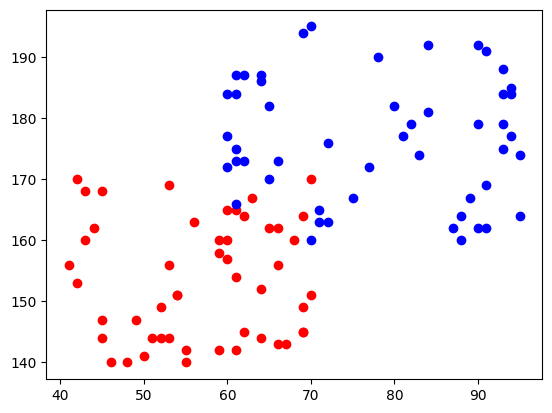

In [30]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')

plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')

# 2. 군집화 로직

In [34]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40, 90), random.randint(140, 195)],
    [random.randint(40, 90), random.randint(140, 195)]
]
random_poinsts[0], random_poinsts[1]

([51, 172], [67, 177])

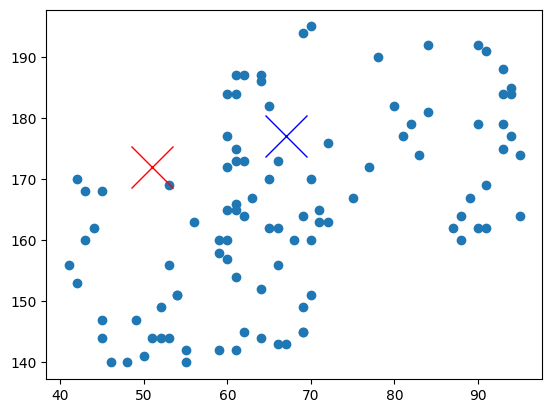

In [36]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='r') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='b') # 기준점0

In [38]:
# 두 점 거리를 return하는 함수 점은 [50, 160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [39]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(40, 60)

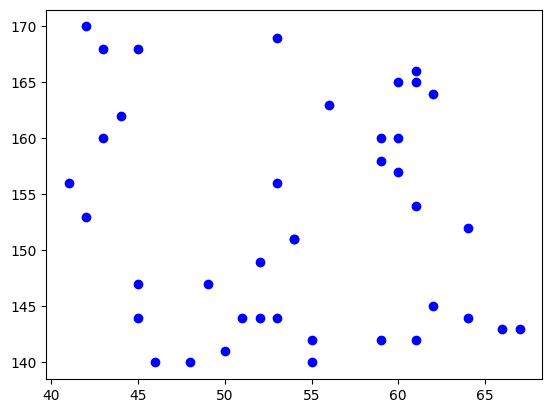

In [41]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')

In [43]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[53.925, 152.725], [76.23333333333333, 173.15]]

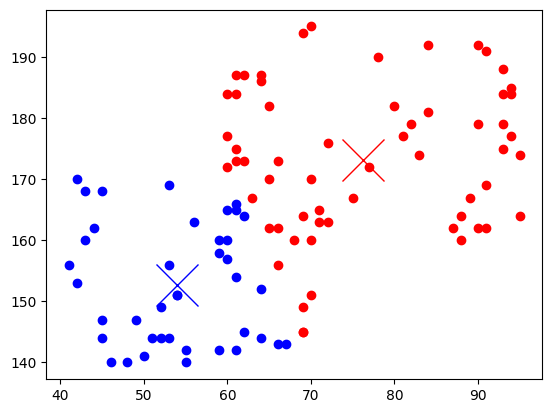

In [44]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()